# AI-Based Hotel Room Rental Demand Prediction & Management System

# Hotel Booking Demand Prediction

## Project Overview

This project focuses on analyzing hotel booking data and predicting daily hotel booking demand using machine learning techniques.

The project covers data understanding, data cleaning, exploratory data analysis, feature engineering, model building, model evaluation, model improvement, and business interpretation.

## 1. Problem Statement

Hotels need to estimate future room rental demand to manage room availability, pricing, staffing, and other resources effectively. The purpose of this project is to use historical hotel booking data and machine learning techniques to predict the expected demand for hotel rooms.

## 2. Project Objective

The main objective of this project is to develop a machine learning system that predicts hotel room rental demand using historical hotel booking data. The system will also provide useful insights to support hotel management decisions related to room availability, pricing, and resource planning.

## 3. Dataset Description

The dataset used in this project is the Hotel Booking Demand dataset. It contains historical hotel booking records with information related to reservations, arrival dates, length of stay, number of guests, room types, booking channels, cancellations, and average daily room rates.

The dataset will be analyzed to identify the factors that can be used to estimate hotel room rental demand.

### Dataset Features

The dataset contains information such as:

- Hotel type
- Booking cancellation status
- Lead time
- Arrival date
- Length of stay
- Number of guests
- Meal type
- Country
- Market segment
- Distribution channel
- Reserved and assigned room type
- Booking changes
- Deposit type
- Average Daily Rate (ADR)
- Reservation status
- Reservation status date

## 4. Data Loading

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("hotel_bookings.csv")

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 5. Dataset Inspection

In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [8]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [9]:
df["hotel"].value_counts()

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64

In [10]:
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [11]:
df["arrival_date_month"].value_counts()

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64

In [12]:
df["reservation_status"].value_counts()

reservation_status
Check-Out    75166
Canceled     43017
No-Show       1207
Name: count, dtype: int64

## 6. Initial Findings

- The dataset contains 119,390 hotel booking records and 32 columns.
- The dataset includes both numerical and categorical features.
- The dataset contains missing values in the children, country, agent, and company columns.
- The dataset contains two hotel types: City Hotel and Resort Hotel.
- There are 75,166 non-canceled bookings and 44,224 canceled bookings.
- August has the highest number of arrival records, while January has the lowest.
- The dataset contains three reservation statuses: Check-Out, Canceled, and No-Show.
- The data contains useful information about arrival dates, length of stay, guest details, room types, booking channels, cancellations, and average daily rate (ADR).

## 7. Data Cleaning

1. Duplicate records check
2. Missing values analyze
3. Data types check
4. Invalid values check
5. Outliers investigate
6. Cleaning decisions
7. Clean dataset verify

In [13]:
df.duplicated().sum()

np.int64(31994)

In [14]:
(df.duplicated().sum() / len(df)) * 100

np.float64(26.797889270458164)

In [15]:
df[df.duplicated()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,...,No Deposit,250.0,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,...,No Deposit,250.0,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07
138,Resort Hotel,1,5,2015,July,28,5,1,0,2,...,No Deposit,240.0,NaN,0,Transient,97.00,0,0,Canceled,2015-07-01
200,Resort Hotel,0,0,2015,July,28,7,0,1,1,...,No Deposit,240.0,NaN,0,Transient,109.80,0,3,Check-Out,2015-07-08


In [16]:
df = df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.isnull().sum()

hotel                                 0
is_canceled                           0
lead_time                             0
arrival_date_year                     0
arrival_date_month                    0
arrival_date_week_number              0
arrival_date_day_of_month             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
meal                                  0
country                             452
market_segment                        0
distribution_channel                  0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
reserved_room_type                    0
assigned_room_type                    0
booking_changes                       0
deposit_type                          0
agent                             12193
company                           82137


In [19]:
(df.isnull().sum() / len(df)) * 100

hotel                              0.000000
is_canceled                        0.000000
lead_time                          0.000000
arrival_date_year                  0.000000
arrival_date_month                 0.000000
arrival_date_week_number           0.000000
arrival_date_day_of_month          0.000000
stays_in_weekend_nights            0.000000
stays_in_week_nights               0.000000
adults                             0.000000
children                           0.004577
babies                             0.000000
meal                               0.000000
country                            0.517186
market_segment                     0.000000
distribution_channel               0.000000
is_repeated_guest                  0.000000
previous_cancellations             0.000000
previous_bookings_not_canceled     0.000000
reserved_room_type                 0.000000
assigned_room_type                 0.000000
booking_changes                    0.000000
deposit_type                    

In [20]:
missing = df.isnull().sum()
missing[missing > 0]

children        4
country       452
agent       12193
company     82137
dtype: int64

In [21]:
df["children"].value_counts()

children
0.0     79028
1.0      4695
2.0      3593
3.0        75
10.0        1
Name: count, dtype: int64

In [22]:
df["children"].isnull().sum()

np.int64(4)

In [23]:
df[df["children"].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [24]:
df["children"] = df["children"].fillna(0)

In [25]:
df["children"].isnull().sum()

np.int64(0)

In [26]:
df["country"].value_counts().head(10)

country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64

In [27]:
df[df["country"].isnull()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
30,Resort Hotel,0,118,2015,July,27,1,4,10,1,...,No Deposit,NaN,NaN,0,Transient,62.0,0,2,Check-Out,2015-07-15
4127,Resort Hotel,1,0,2016,February,8,15,0,0,0,...,No Deposit,NaN,383.0,0,Transient,0.0,0,0,Canceled,2016-02-15
7092,Resort Hotel,1,8,2016,July,30,21,0,1,1,...,No Deposit,NaN,204.0,0,Transient,73.0,0,2,Canceled,2016-07-20
7860,Resort Hotel,1,39,2016,August,36,30,0,5,2,...,No Deposit,NaN,NaN,0,Transient,159.0,0,5,Canceled,2016-07-22
8779,Resort Hotel,1,0,2016,October,42,13,0,1,1,...,No Deposit,NaN,457.0,0,Transient,50.0,0,0,Canceled,2016-10-13


In [28]:
df["country"] = df["country"].fillna("Unknown")

In [29]:
df["country"].isnull().sum()

np.int64(0)

In [30]:
df["agent"].value_counts().head(10)

agent
9.0      28759
240.0    13028
14.0      3349
7.0       3300
250.0     2779
241.0     1644
28.0      1502
8.0       1383
1.0       1232
6.0       1117
Name: count, dtype: int64

In [31]:
df[df["agent"].isnull()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
18,Resort Hotel,0,0,2015,July,27,1,0,1,2,...,No Deposit,NaN,110.0,0,Transient,107.42,0,0,Check-Out,2015-07-02


In [32]:
df["agent"] = df["agent"].fillna(0)

In [33]:
df["agent"].isnull().sum()

np.int64(0)

In [34]:
df["company"].value_counts().head(10)

company
40.0     851
223.0    503
45.0     238
153.0    206
154.0    133
219.0    131
174.0    121
281.0    119
233.0     95
51.0      80
Name: count, dtype: int64

In [35]:
df[df["company"].isnull()].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,0.0,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,0.0,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,0.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [36]:
df["company"] = df["company"].fillna(0)

In [37]:
df["company"].isnull().sum()

np.int64(0)

In [38]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [39]:
df[["reservation_status_date"]].head()

,reservation_status_date
0,2015-07-01
1,2015-07-01
2,2015-07-02
3,2015-07-02
4,2015-07-03


In [40]:
df["reservation_status_date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [41]:
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])

In [42]:
df["reservation_status_date"].dtype

dtype('<M8[us]')

In [43]:
df["adults"].value_counts()

adults
2     64497
1     16503
3      5935
0       385
4        60
26        5
27        2
20        2
5         2
40        1
50        1
55        1
6         1
10        1
Name: count, dtype: int64

In [44]:
df[df["adults"] == 0].head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2224,Resort Hotel,0,1,2015,October,41,6,0,3,0,...,No Deposit,0.0,174.0,0,Transient-Party,0.0,0,0,Check-Out,2015-10-06
2409,Resort Hotel,0,0,2015,October,42,12,0,0,0,...,No Deposit,0.0,174.0,0,Transient,0.0,0,0,Check-Out,2015-10-12
3181,Resort Hotel,0,36,2015,November,47,20,1,2,0,...,No Deposit,38.0,0.0,0,Transient-Party,0.0,0,0,Check-Out,2015-11-23
3684,Resort Hotel,0,165,2015,December,53,30,1,4,0,...,No Deposit,308.0,0.0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-04
3708,Resort Hotel,0,165,2015,December,53,30,2,4,0,...,No Deposit,308.0,0.0,122,Transient-Party,0.0,0,0,Check-Out,2016-01-05


In [45]:
df.loc[df["adults"] == 0, ["adults", "children", "babies", "is_canceled", "hotel"]].head(10)

,adults,children,babies,is_canceled,hotel
2224,0,0.0,0,0,Resort Hotel
2409,0,0.0,0,0,Resort Hotel
3181,0,0.0,0,0,Resort Hotel
3684,0,0.0,0,0,Resort Hotel
3708,0,0.0,0,0,Resort Hotel
4127,0,0.0,0,1,Resort Hotel
9376,0,0.0,0,1,Resort Hotel
31765,0,0.0,0,0,Resort Hotel
32029,0,0.0,0,0,Resort Hotel
32827,0,0.0,0,0,Resort Hotel


In [46]:
df[(df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)].shape

(166, 32)

In [47]:
df = df[~((df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0))]

In [48]:
df[(df["adults"] == 0) & (df["children"] == 0) & (df["babies"] == 0)].shape

(0, 32)

In [49]:
df["adr"].describe()

count    87230.000000
mean       106.518031
std         54.891227
min         -6.380000
25%         72.250000
50%         98.200000
75%        134.100000
max       5400.000000
Name: adr, dtype: float64

In [50]:
df[df["adr"] < 0]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,273.0,0.0,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [51]:
df = df[df["adr"] >= 0]

In [52]:
(df["adr"] < 0).sum()

np.int64(0)

In [53]:
df["stays_in_weekend_nights"].value_counts()

stays_in_weekend_nights
0     35058
2     26376
1     22646
4      1725
3      1143
6       112
5        68
8        58
7        15
9         9
10        7
12        5
13        2
16        2
18        1
19        1
14        1
Name: count, dtype: int64

In [54]:
df["stays_in_week_nights"].value_counts()

stays_in_week_nights
1     22173
2     20730
3     16242
5      9654
4      7857
0      6112
6      1374
10      966
7       962
8       611
9       216
15       68
11       49
12       40
20       39
13       27
14       25
19       20
21       15
16       12
22        7
25        6
18        6
30        4
17        4
24        2
40        2
33        1
42        1
50        1
32        1
26        1
34        1
Name: count, dtype: int64

In [55]:
df["babies"].value_counts()

babies
0     86315
1       897
2        15
10        1
9         1
Name: count, dtype: int64

In [56]:
df["booking_changes"].value_counts()

booking_changes
0     71425
1     10868
2      3482
3       862
4       347
5       113
6        57
7        29
8        14
9         8
10        6
13        5
14        3
15        3
17        2
16        2
12        1
18        1
11        1
Name: count, dtype: int64

In [57]:
df["previous_cancellations"].value_counts()

previous_cancellations
0     85548
1      1405
2       110
3        61
4        30
11       27
5        19
6        17
13        4
25        2
24        2
26        1
14        1
19        1
21        1
Name: count, dtype: int64

In [58]:
df["previous_bookings_not_canceled"].value_counts()

previous_bookings_not_canceled
0     83692
1      1478
2       579
3       331
4       228
      ...  
68        1
69        1
70        1
71        1
72        1
Name: count, Length: 73, dtype: int64

In [59]:
df["lead_time"].describe()

count    87229.000000
mean        79.969700
std         86.058295
min          0.000000
25%         11.000000
50%         49.000000
75%        125.000000
max        737.000000
Name: lead_time, dtype: float64

In [60]:
df["required_car_parking_spaces"].value_counts()

required_car_parking_spaces
0    79923
1     7273
2       28
3        3
8        2
Name: count, dtype: int64

In [61]:
df["total_of_special_requests"].value_counts()

total_of_special_requests
0    43788
1    28976
2    11795
3     2314
4      320
5       36
Name: count, dtype: int64

In [62]:
df["deposit_type"].value_counts()

deposit_type
No Deposit    86084
Non Refund     1038
Refundable      107
Name: count, dtype: int64

In [63]:
df["hotel"].value_counts()

hotel
City Hotel      53274
Resort Hotel    33955
Name: count, dtype: int64

In [64]:
df["customer_type"].value_counts()

customer_type
Transient          71862
Transient-Party    11691
Contract            3135
Group                541
Name: count, dtype: int64

In [65]:
df.select_dtypes(include="number").lt(0).sum()

is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
booking_changes                   0
agent                             0
company                           0
days_in_waiting_list              0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

In [66]:
Q1 = df["adr"].quantile(0.25)
Q3 = df["adr"].quantile(0.75)
IQR = Q3 - Q1

Q1, Q3, IQR

(np.float64(72.25), np.float64(134.1), np.float64(61.849999999999994))

In [67]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

lower_bound, upper_bound

(np.float64(-20.52499999999999), np.float64(226.875))

In [68]:
(df["adr"] > upper_bound).sum()

np.int64(2508)

In [69]:
df[df["adr"] > upper_bound][["hotel", "adr", "adults", "children", "babies", "reserved_room_type"]].head(10)

,hotel,adr,adults,children,babies,reserved_room_type
396,Resort Hotel,230.67,2,2.0,0,H
523,Resort Hotel,249.00,2,2.0,0,C
526,Resort Hotel,241.50,2,1.0,0,D
584,Resort Hotel,240.64,2,1.0,0,F
641,Resort Hotel,233.00,2,2.0,0,G
683,Resort Hotel,240.00,2,2.0,0,G
695,Resort Hotel,233.05,3,0.0,0,E
780,Resort Hotel,240.00,3,0.0,0,H
799,Resort Hotel,250.33,3,1.0,0,G
803,Resort Hotel,280.74,2,2.0,0,C


In [70]:
Q1_lead = df["lead_time"].quantile(0.25)
Q3_lead = df["lead_time"].quantile(0.75)
IQR_lead = Q3_lead - Q1_lead

Q1_lead, Q3_lead, IQR_lead

(np.float64(11.0), np.float64(125.0), np.float64(114.0))

In [71]:
lower_lead = Q1_lead - 1.5 * IQR_lead
upper_lead = Q3_lead + 1.5 * IQR_lead

lower_lead, upper_lead

(np.float64(-160.0), np.float64(296.0))

In [72]:
(df["lead_time"] > upper_lead).sum()

np.int64(2394)

## 6. Cleaning Decisions

- Duplicate records were checked and no duplicate records were found.
- Missing values in the children, country, agent, and company columns were handled.
- Missing children values were replaced with 0.
- Missing country values were replaced with "Unknown".
- Missing agent values were replaced with 0.
- Missing company values were replaced with 0.
- Records with zero adults, zero children, and zero babies were removed because they do not represent meaningful guest bookings.
- Negative ADR values were identified and removed because room rates cannot be negative.
- Statistical outliers in ADR and lead_time were investigated using the IQR method.
- High ADR values were retained because they may represent genuine high-priced hotel bookings.
- High lead_time values were retained because they may represent genuine advance bookings.
- No unnecessary outlier removal was performed to avoid losing useful information.

In [73]:
df.isnull().sum().sum()

np.int64(0)

In [74]:
df.duplicated().sum()

np.int64(0)

 

## 1. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the cleaned hotel booking dataset using statistical summaries and visualizations.

The main objectives of EDA are:

- Understand the distribution of important features.
- Identify booking and cancellation patterns.
- Analyze hotel-wise and month-wise demand.
- Study customer and room-type preferences.
- Analyze ADR, lead time, and length of stay.
- Identify relationships between important numerical variables.
- Extract useful insights for hotel room rental demand prediction.

In [75]:
df.shape

(87229, 32)

In [76]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
count,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,...,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229.000000,87229
mean,0.275241,79.969700,2016.210343,26.835284,15.815956,1.004574,2.623887,1.879364,0.138899,0.010845,...,0.030403,0.184033,0.268477,81.087058,10.985074,0.746300,106.519325,0.084307,0.698942,2016-08-31 02:51:08.474934
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014-10-17 00:00:00
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,72.250000,0.000000,0.000000,2016-03-18 00:00:00
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,9.000000,0.000000,0.000000,98.200000,0.000000,0.000000,2016-09-08 00:00:00
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,240.000000,0.000000,0.000000,134.100000,0.000000,1.000000,2017-03-05 00:00:00
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,...,26.000000,72.000000,18.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000,2017-09-14 00:00:00
std,0.446638,86.058295,0.686063,13.669175,8.835520,1.027364,2.039810,0.621727,0.456267,0.113704,...,0.369347,1.733033,0.710612,109.975966,53.956964,10.001058,54.890211,0.281660,0.832052,NaN


In [77]:
df["adr"].describe()

count    87229.000000
mean       106.519325
std         54.890211
min          0.000000
25%         72.250000
50%         98.200000
75%        134.100000
max       5400.000000
Name: adr, dtype: float64

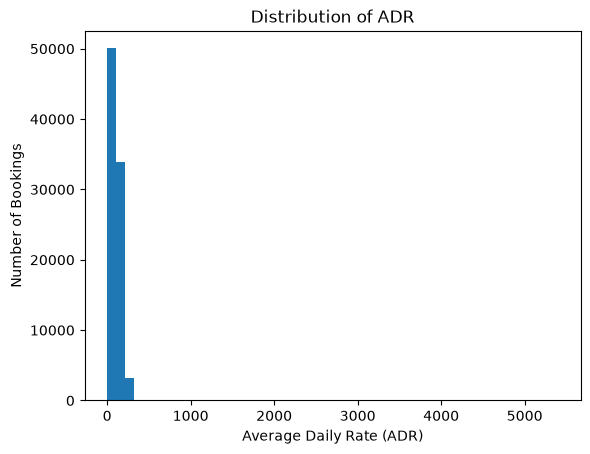

In [78]:
import matplotlib.pyplot as plt

plt.hist(df["adr"], bins=50)
plt.xlabel("Average Daily Rate (ADR)")
plt.ylabel("Number of Bookings")
plt.title("Distribution of ADR")
plt.show()

### ADR Distribution Finding

The ADR distribution is right-skewed, with most bookings concentrated at lower ADR values. A small number of bookings have very high ADR values, creating a long right tail in the distribution. These high values were retained because they may represent genuine high-priced hotel bookings.

In [79]:
df["hotel"].value_counts()

hotel
City Hotel      53274
Resort Hotel    33955
Name: count, dtype: int64

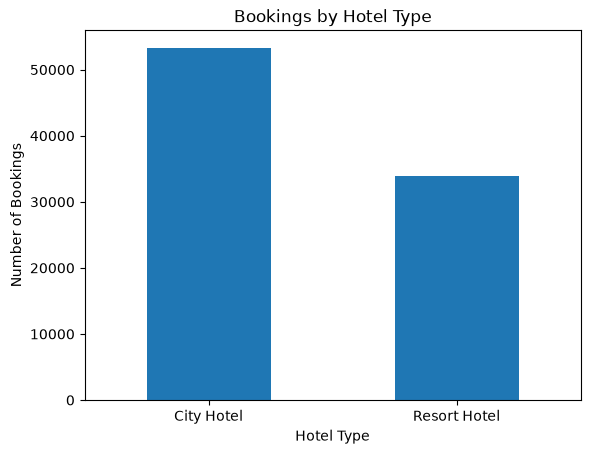

In [80]:
import matplotlib.pyplot as plt

df["hotel"].value_counts().plot(kind="bar")

plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")
plt.title("Bookings by Hotel Type")
plt.xticks(rotation=0)
plt.show()

### Hotel-wise Booking Finding

City Hotel has a higher number of bookings than Resort Hotel. The dataset contains 53,274 bookings for City Hotel and 33,955 bookings for Resort Hotel. This indicates that City Hotel contributes a larger share of the total booking records.

In [81]:
df["is_canceled"].value_counts()

is_canceled
0    63220
1    24009
Name: count, dtype: int64

In [82]:
cancellation_rate = df["is_canceled"].mean() * 100
cancellation_rate

np.float64(27.52410322255213)

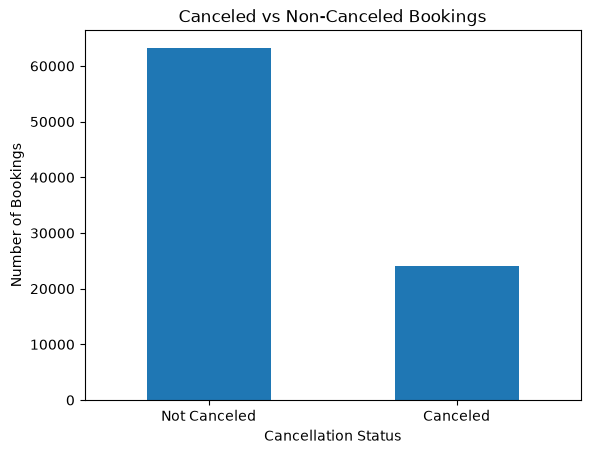

In [83]:
df["is_canceled"].value_counts().plot(kind="bar")

plt.xlabel("Cancellation Status")
plt.ylabel("Number of Bookings")
plt.title("Canceled vs Non-Canceled Bookings")
plt.xticks([0, 1], ["Not Canceled", "Canceled"], rotation=0)
plt.show()

### Cancellation Analysis Finding

The dataset contains 63,220 non-canceled bookings and 24,009 canceled bookings. Approximately 27.52% of the bookings were canceled, while the majority of bookings were not canceled.

In [84]:
df["arrival_date_month"].value_counts()

arrival_date_month
August       11242
July         10043
May           8344
April         7900
June          7756
March         7488
October       6921
September     6682
February      6083
December      5112
November      4973
January       4685
Name: count, dtype: int64

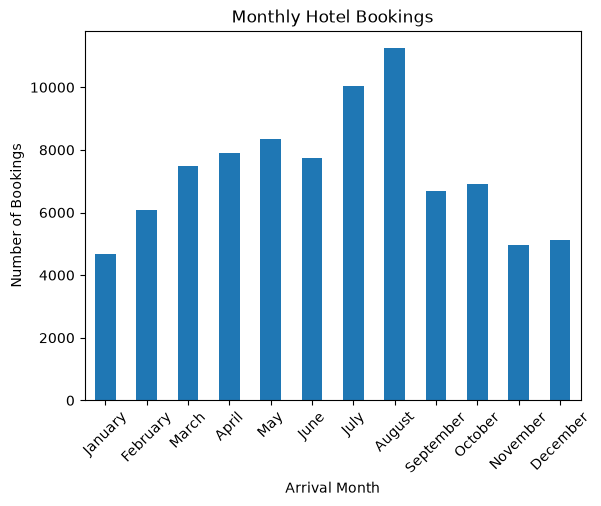

In [85]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_bookings = df["arrival_date_month"].value_counts().reindex(month_order)

monthly_bookings.plot(kind="bar")

plt.xlabel("Arrival Month")
plt.ylabel("Number of Bookings")
plt.title("Monthly Hotel Bookings")
plt.xticks(rotation=45)
plt.show()

### Monthly Booking Finding

August has the highest number of hotel bookings with 11,242 bookings, followed by July with 10,043 bookings. January has the lowest number of bookings with 4,685. The booking volume generally increases from the beginning of the year and reaches its highest level during July and August.

In [86]:
df["arrival_date_year"].value_counts().sort_index()

arrival_date_year
2015    13284
2016    42313
2017    31632
Name: count, dtype: int64

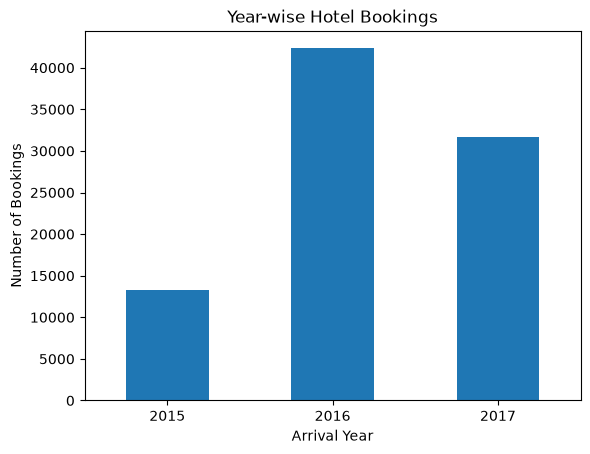

In [87]:
yearly_bookings = df["arrival_date_year"].value_counts().sort_index()

yearly_bookings.plot(kind="bar")

plt.xlabel("Arrival Year")
plt.ylabel("Number of Bookings")
plt.title("Year-wise Hotel Bookings")
plt.xticks(rotation=0)
plt.show()

### Year-wise Booking Finding

The highest number of hotel bookings was recorded in 2016, with 42,313 bookings. In comparison, 2015 had 13,284 bookings and 2017 had 31,632 bookings. Therefore, 2016 represents the year with the highest booking volume in the dataset.

In [88]:
df["customer_type"].value_counts()

customer_type
Transient          71862
Transient-Party    11691
Contract            3135
Group                541
Name: count, dtype: int64

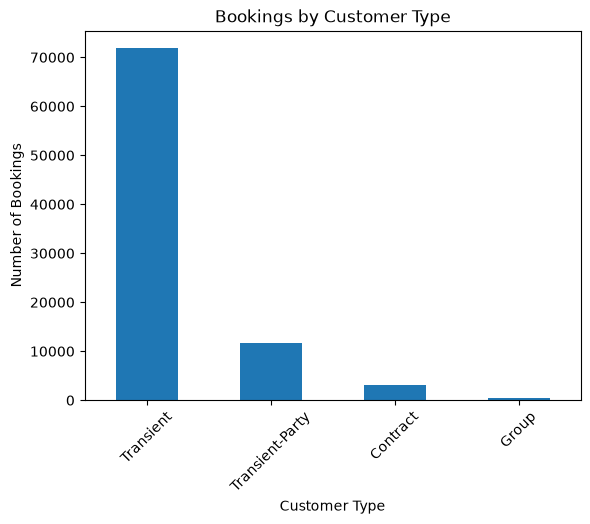

In [89]:
customer_counts = df["customer_type"].value_counts()

customer_counts.plot(kind="bar")

plt.xlabel("Customer Type")
plt.ylabel("Number of Bookings")
plt.title("Bookings by Customer Type")
plt.xticks(rotation=45)
plt.show()

### Customer Type Finding

Transient customers account for the highest number of bookings with 71,862 bookings. They are followed by Transient-Party customers with 11,691 bookings, Contract customers with 3,135 bookings, and Group customers with 541 bookings. This shows that transient customers form the dominant customer segment in the dataset.

In [90]:
df["reserved_room_type"].value_counts()

reserved_room_type
A    56435
D    17376
E     6036
F     2820
G     2050
B      996
C      914
H      596
L        6
Name: count, dtype: int64

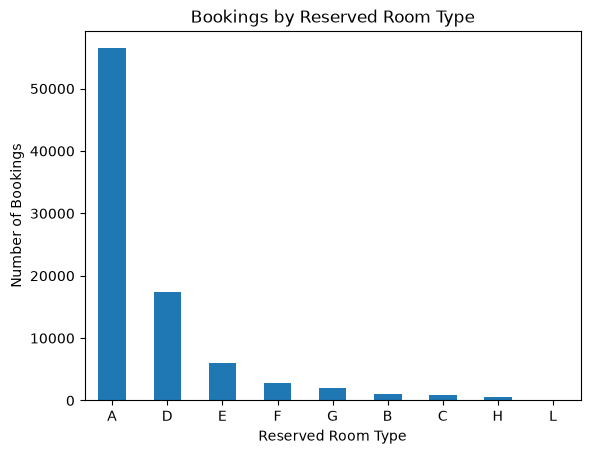

In [91]:
room_counts = df["reserved_room_type"].value_counts()

room_counts.plot(kind="bar")

plt.xlabel("Reserved Room Type")
plt.ylabel("Number of Bookings")
plt.title("Bookings by Reserved Room Type")
plt.xticks(rotation=0)
plt.show()

### Room Type Finding

Room Type A is the most frequently reserved room type, with 56,435 bookings. Room Type D is the second most common with 17,376 bookings. Room Type L has the lowest number of bookings, with only 6 bookings. Overall, Room Type A dominates the reserved room type distribution.

In [92]:
df["total_stay_nights"] = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
)

df["total_stay_nights"].describe()

count    87229.000000
mean         3.628461
std          2.742879
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         69.000000
Name: total_stay_nights, dtype: float64

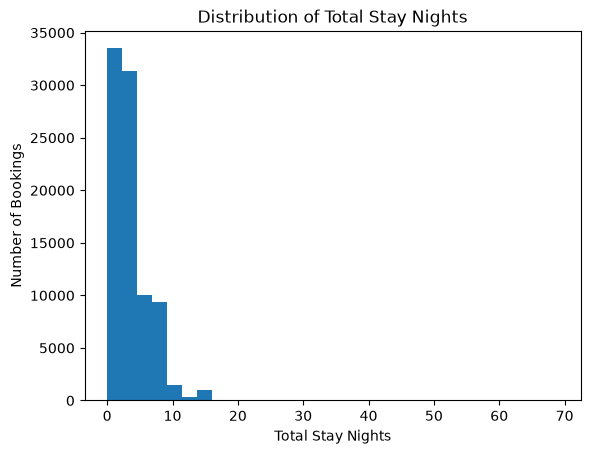

In [93]:
plt.hist(df["total_stay_nights"], bins=30)

plt.xlabel("Total Stay Nights")
plt.ylabel("Number of Bookings")
plt.title("Distribution of Total Stay Nights")
plt.show()

### Length of Stay Finding

Most hotel bookings are for relatively short stays, with the highest concentration around 1 to 5 nights. The median total stay is 3 nights, while the average stay is approximately 3.63 nights. The number of bookings decreases as the length of stay increases, with a small number of bookings having much longer stays.

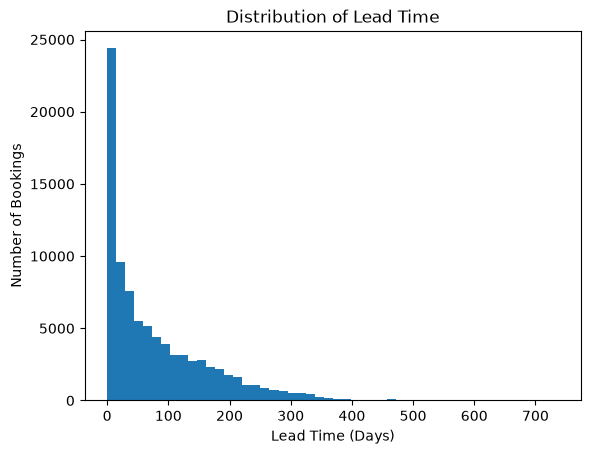

In [94]:
plt.hist(df["lead_time"], bins=50)

plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")
plt.title("Distribution of Lead Time")
plt.show()

### Lead Time Finding

The lead time distribution is right-skewed, with most bookings made within a relatively short period before arrival. The median lead time is 49 days, while the average lead time is approximately 79.97 days. A smaller number of bookings are made several hundred days in advance, creating a long right tail.

In [95]:
df["total_of_special_requests"].value_counts().sort_index()

total_of_special_requests
0    43788
1    28976
2    11795
3     2314
4      320
5       36
Name: count, dtype: int64

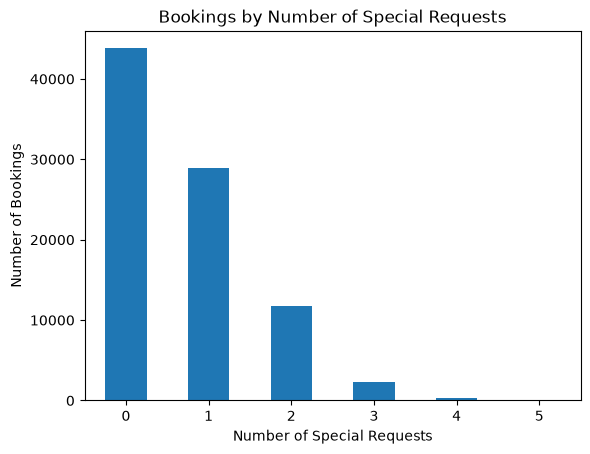

In [96]:
special_requests = df["total_of_special_requests"].value_counts().sort_index()

special_requests.plot(kind="bar")

plt.xlabel("Number of Special Requests")
plt.ylabel("Number of Bookings")
plt.title("Bookings by Number of Special Requests")
plt.xticks(rotation=0)
plt.show()

### Special Requests Finding

Most bookings have no special requests, with 43,788 bookings having zero requests. A total of 28,976 bookings have one special request, while the number of bookings decreases as the number of requests increases. Only 36 bookings have five special requests.

In [97]:
corr = df[
    [
        "is_canceled",
        "lead_time",
        "adr",
        "total_stay_nights",
        "adults",
        "previous_cancellations",
        "booking_changes",
        "total_of_special_requests"
    ]
].corr()

corr

,is_canceled,lead_time,adr,total_stay_nights,adults,previous_cancellations,booking_changes,total_of_special_requests
is_canceled,1.000000,0.184527,0.127221,0.085450,0.080272,0.051500,-0.093223,-0.120800
lead_time,0.184527,1.000000,0.021980,0.320892,0.139032,0.005372,0.080788,0.034061
adr,0.127221,0.021980,1.000000,0.056160,0.242006,-0.050362,0.010202,0.137445
total_stay_nights,0.085450,0.320892,0.056160,1.000000,0.108115,-0.021633,0.062306,0.040824
adults,0.080272,0.139032,0.242006,0.108115,1.000000,-0.042389,-0.036453,0.112512
previous_cancellations,0.051500,0.005372,-0.050362,-0.021633,-0.042389,1.000000,-0.010265,0.001694
booking_changes,-0.093223,0.080788,0.010202,0.062306,-0.036453,-0.010265,1.000000,0.018332
total_of_special_requests,-0.120800,0.034061,0.137445,0.040824,0.112512,0.001694,0.018332,1.000000


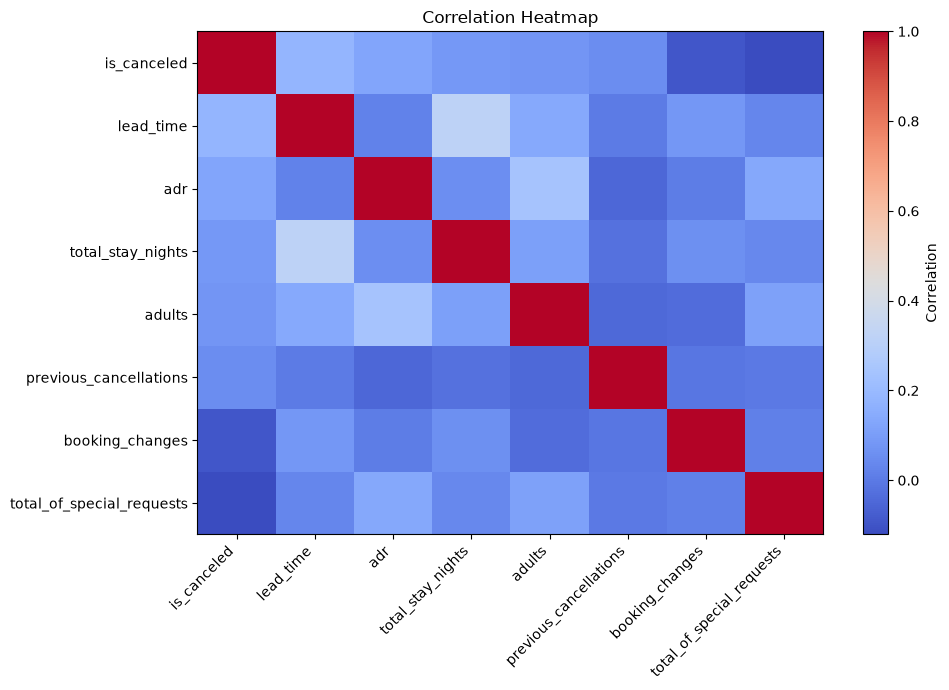

In [98]:
plt.figure(figsize=(10, 7))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Correlation Analysis Finding

The correlation analysis shows that most numerical variables have weak linear relationships with each other.

The strongest observed relationship is between lead_time and total_stay_nights, with a correlation of approximately 0.321, indicating a weak-to-moderate positive relationship.

The correlation between is_canceled and lead_time is approximately 0.184, while the correlation between is_canceled and adr is approximately 0.127. The correlation between is_canceled and total_of_special_requests is approximately -0.121.

Overall, no very strong correlation was observed among the selected numerical features.

## 13. EDA Findings

- The cleaned dataset contains 87,229 booking records and 32 columns.
- City Hotel has more bookings (53,274) than Resort Hotel (33,955).
- 24,009 bookings were canceled, while 63,220 were not canceled.
- The overall cancellation rate is approximately 27.52%.
- August has the highest number of bookings with 11,242 bookings, while January has the lowest with 4,685 bookings.
- 2016 has the highest number of bookings with 42,313 records.
- Transient customers form the largest customer segment with 71,862 bookings.
- Room Type A is the most frequently reserved room type with 56,435 bookings.
- The average total stay is approximately 3.63 nights, with a median of 3 nights.
- Most bookings have relatively short stays, mainly around 1 to 5 nights.
- The lead time distribution is right-skewed, with a median of 49 days and an average of approximately 79.97 days.
- Most bookings have no special requests.
- The ADR distribution is right-skewed, with most bookings concentrated at lower ADR values.
- Correlation analysis shows mostly weak relationships among the selected numerical variables.
- The strongest observed relationship is between lead_time and total_stay_nights, with a correlation of approximately 0.321.
- No very strong correlation was observed among the selected numerical features.

# Feature Engineering & Data Preparation

## Objective

The objective of this step is to prepare the cleaned hotel booking dataset for machine learning.

The main tasks are:

- Identify the target variable.
- Select relevant features for prediction.
- Remove unnecessary columns.
- Create useful features from existing data.
- Encode categorical variables.
- Prepare numerical features.
- Create the feature matrix (X) and target variable (y).
- Split the data into training and testing sets.
- Verify the final model-ready dataset.

In [99]:
df.columns.tolist()

['hotel',
 'is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_month',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'reserved_room_type',
 'assigned_room_type',
 'booking_changes',
 'deposit_type',
 'agent',
 'company',
 'days_in_waiting_list',
 'customer_type',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'reservation_status',
 'reservation_status_date',
 'total_stay_nights']

In [100]:
df[
    [
        "arrival_date_year",
        "arrival_date_month",
        "arrival_date_day_of_month"
    ]
].head()

,arrival_date_year,arrival_date_month,arrival_date_day_of_month
0,2015,July,1
1,2015,July,1
2,2015,July,1
3,2015,July,1
4,2015,July,1


In [101]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str)
)

df["arrival_date"].head()

0   2015-07-01
1   2015-07-01
2   2015-07-01
3   2015-07-01
4   2015-07-01
Name: arrival_date, dtype: datetime64[us]

In [102]:
daily_demand = df.groupby("arrival_date").size()

daily_demand.head()

arrival_date
2015-07-01    53
2015-07-02    54
2015-07-03    51
2015-07-04    60
2015-07-05    52
dtype: int64

In [103]:
demand_df = daily_demand.reset_index(name="demand")

demand_df.head()

,arrival_date,demand
0,2015-07-01,53
1,2015-07-02,54
2,2015-07-03,51
3,2015-07-04,60
4,2015-07-05,52


In [104]:
demand_df["demand"].describe()

count    793.000000
mean     109.998739
std       39.307082
min       18.000000
25%       81.000000
50%      112.000000
75%      137.000000
max      237.000000
Name: demand, dtype: float64

### Daily Demand Finding

The dataset contains 793 daily observations of hotel booking demand. The average daily demand is approximately 110 bookings, while the median daily demand is 112 bookings. Daily demand ranges from 18 to 237 bookings. The standard deviation is approximately 39.31, indicating variation in the number of bookings across different arrival dates.

In [105]:
demand_df["day_of_week"] = demand_df["arrival_date"].dt.dayofweek

demand_df.head()

,arrival_date,demand,day_of_week
0,2015-07-01,53,2
1,2015-07-02,54,3
2,2015-07-03,51,4
3,2015-07-04,60,5
4,2015-07-05,52,6


In [106]:
demand_df["month"] = demand_df["arrival_date"].dt.month

demand_df.head()

,arrival_date,demand,day_of_week,month
0,2015-07-01,53,2,7
1,2015-07-02,54,3,7
2,2015-07-03,51,4,7
3,2015-07-04,60,5,7
4,2015-07-05,52,6,7


In [107]:
demand_df["year"] = demand_df["arrival_date"].dt.year

demand_df.head()

,arrival_date,demand,day_of_week,month,year
0,2015-07-01,53,2,7,2015
1,2015-07-02,54,3,7,2015
2,2015-07-03,51,4,7,2015
3,2015-07-04,60,5,7,2015
4,2015-07-05,52,6,7,2015


In [108]:
demand_df.shape

(793, 5)

In [109]:
demand_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 793 entries, 0 to 792
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   arrival_date  793 non-null    datetime64[us]
 1   demand        793 non-null    int64         
 2   day_of_week   793 non-null    int32         
 3   month         793 non-null    int32         
 4   year          793 non-null    int32         
dtypes: datetime64[us](1), int32(3), int64(1)
memory usage: 21.8 KB


In [110]:
X = demand_df[["day_of_week", "month", "year"]]

X.head()

,day_of_week,month,year
0,2,7,2015
1,3,7,2015
2,4,7,2015
3,5,7,2015
4,6,7,2015


In [111]:
y = demand_df["demand"]

y.head()

0    53
1    54
2    51
3    60
4    52
Name: demand, dtype: int64

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((634, 3), (159, 3), (634,), (159,))

In [113]:
X_train.isnull().sum(), X_test.isnull().sum(), y_train.isnull().sum(), y_test.isnull().sum()

(day_of_week    0
 month          0
 year           0
 dtype: int64,
 day_of_week    0
 month          0
 year           0
 dtype: int64,
 np.int64(0),
 np.int64(0))

In [114]:
print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

print("\nTraining data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Features (X):
['day_of_week', 'month', 'year']

Target (y):
demand

Training data shape: (634, 3)
Testing data shape: (159, 3)


In [115]:
model_data = demand_df[[
    "arrival_date",
    "day_of_week",
    "month",
    "year",
    "demand"
]].copy()

model_data.head()

,arrival_date,day_of_week,month,year,demand
0,2015-07-01,2,7,2015,53
1,2015-07-02,3,7,2015,54
2,2015-07-03,4,7,2015,51
3,2015-07-04,5,7,2015,60
4,2015-07-05,6,7,2015,52


In [116]:
print("Missing values:", model_data.isnull().sum().sum())
print("Duplicate rows:", model_data.duplicated().sum())
print("Shape:", model_data.shape)

Missing values: 0
Duplicate rows: 0
Shape: (793, 5)


##  Feature Engineering & Data Preparation Summary

- The arrival date was converted into a proper datetime format.
- Daily booking demand was created by counting bookings for each arrival date.
- The demand dataset contains 793 daily observations.
- Day of week, month, and year features were extracted from the arrival date.
- The target variable was defined as daily booking demand.
- The feature matrix (X) contains day_of_week, month, and year.
- The target variable (y) is demand.
- The data was divided into training and testing sets using an 80:20 split.
- The training set contains 634 observations and the testing set contains 159 observations.
- No missing values were found in the model-ready dataset.
- No duplicate rows were found in the model-ready dataset.
- The final model-ready dataset contains 793 rows and 5 columns.

#  Model Building & Evaluation

## Objective

The objective of this step is to build machine learning models for predicting daily hotel booking demand.

The prepared features will be used to train regression models, and their performance will be evaluated using appropriate regression metrics.

The main tasks are:

- Prepare the training and testing data.
- Build a baseline model.
- Train regression models.
- Generate demand predictions.
- Evaluate model performance using MAE, RMSE, and R².
- Compare the models and identify the better-performing model.
- Visualize actual versus predicted demand.

In [117]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import matplotlib.pyplot as plt

In [118]:
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_pred[:5]

array([109.20977918, 109.20977918, 109.20977918, 109.20977918,
       109.20977918])

In [119]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 30.549897823542253
Baseline RMSE: 37.3261595928665
Baseline R²: -0.011237989453916297


In [120]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_pred[:5]

array([ 81.8634657 ,  86.49498553, 142.58102608, 127.22048109,
       132.2143107 ])

In [121]:
linear_mae = mean_absolute_error(y_test, linear_pred)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_pred)
)

linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 26.511504348565598
Linear Regression RMSE: 33.06632020070365
Linear Regression R²: 0.20640578521753994


In [122]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_pred[:5]

array([ 36.33632864,  60.11564087, 137.51332143, 140.08108333,
       136.91032143])

In [123]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 22.60807402677686
Random Forest RMSE: 28.448541710120647
Random Forest R²: 0.41258263952497254


In [124]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

model_comparison

,Model,MAE,RMSE,R2
0,Baseline,30.549898,37.326160,-0.011238
1,Linear Regression,26.511504,33.066320,0.206406
2,Random Forest,22.608074,28.448542,0.412583


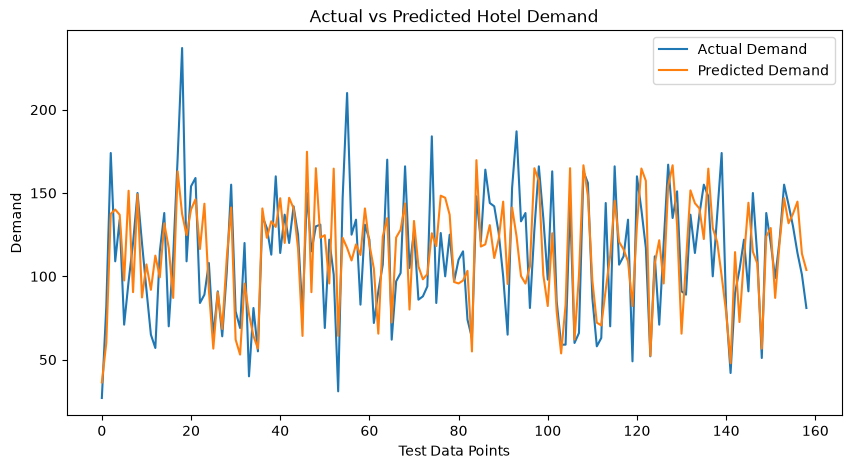

In [125]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values, label="Actual Demand")
plt.plot(rf_pred, label="Predicted Demand")

plt.xlabel("Test Data Points")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Hotel Demand")
plt.legend()
plt.show()

In [126]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
2,year,0.432334
1,month,0.364654
0,day_of_week,0.203012


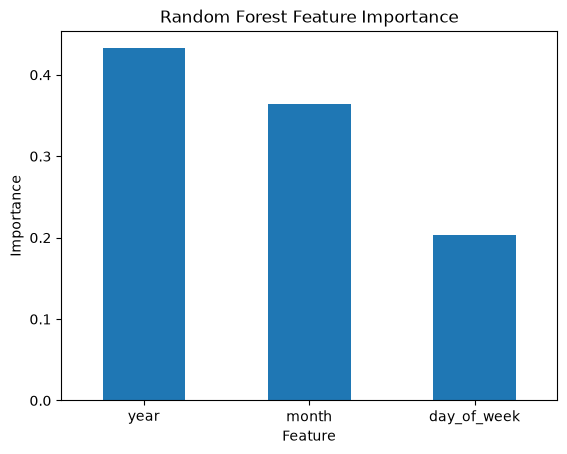

In [127]:
feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="bar",
    legend=False
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.xticks(rotation=0)
plt.show()

##  Model Building & Evaluation Findings

- A baseline model was created using the mean demand as the prediction.
- Linear Regression performed better than the baseline model.
- Random Forest Regressor achieved the best performance among the tested models.
- Random Forest achieved an MAE of approximately 22.61 bookings.
- Random Forest achieved an RMSE of approximately 28.45 bookings.
- Random Forest achieved an R² score of approximately 0.413.
- The actual versus predicted demand plot shows that the Random Forest model generally follows the actual demand pattern, although some prediction errors remain.
- Among the selected features, year had the highest Random Forest feature importance (0.4323), followed by month (0.3647) and day_of_week (0.2030).
- Overall, Random Forest performed better than both the baseline and Linear Regression models for the current feature set.

# Model Improvement

## Objective

The objective of this step is to improve the hotel booking demand prediction model by creating additional time-based features from historical demand.

The main tasks are:

- Create additional time-based features.
- Create lag features from historical demand.
- Create rolling demand features.
- Use a time-based train-test split.
- Train an improved Random Forest model.
- Evaluate the improved model using MAE, RMSE, and R².
- Compare the improved model with the previous models.
- Identify the best-performing model.

In [128]:
demand_df["week_of_year"] = demand_df["arrival_date"].dt.isocalendar().week.astype(int)

demand_df["is_weekend"] = demand_df["day_of_week"].isin([5, 6]).astype(int)

demand_df.head()

,arrival_date,demand,day_of_week,month,year,week_of_year,is_weekend
0,2015-07-01,53,2,7,2015,27,0
1,2015-07-02,54,3,7,2015,27,0
2,2015-07-03,51,4,7,2015,27,0
3,2015-07-04,60,5,7,2015,27,1
4,2015-07-05,52,6,7,2015,27,1


In [129]:
demand_df["lag_1"] = demand_df["demand"].shift(1)

demand_df.head()

,arrival_date,demand,day_of_week,month,year,week_of_year,is_weekend,lag_1
0,2015-07-01,53,2,7,2015,27,0,NaN
1,2015-07-02,54,3,7,2015,27,0,53.0
2,2015-07-03,51,4,7,2015,27,0,54.0
3,2015-07-04,60,5,7,2015,27,1,51.0
4,2015-07-05,52,6,7,2015,27,1,60.0


In [130]:
demand_df["lag_7"] = demand_df["demand"].shift(7)

demand_df.head(10)

,arrival_date,demand,day_of_week,month,year,week_of_year,is_weekend,lag_1,lag_7
0,2015-07-01,53,2,7,2015,27,0,NaN,NaN
1,2015-07-02,54,3,7,2015,27,0,53.0,NaN
2,2015-07-03,51,4,7,2015,27,0,54.0,NaN
3,2015-07-04,60,5,7,2015,27,1,51.0,NaN
4,2015-07-05,52,6,7,2015,27,1,60.0,NaN
5,2015-07-06,55,0,7,2015,28,0,52.0,NaN
6,2015-07-07,52,1,7,2015,28,0,55.0,NaN
7,2015-07-08,42,2,7,2015,28,0,52.0,53.0
8,2015-07-09,41,3,7,2015,28,0,42.0,54.0
9,2015-07-10,48,4,7,2015,28,0,41.0,51.0


In [131]:
demand_df["rolling_7"] = (
    demand_df["demand"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

demand_df.head(10)

,arrival_date,demand,day_of_week,month,year,week_of_year,is_weekend,lag_1,lag_7,rolling_7
0,2015-07-01,53,2,7,2015,27,0,NaN,NaN,NaN
1,2015-07-02,54,3,7,2015,27,0,53.0,NaN,NaN
2,2015-07-03,51,4,7,2015,27,0,54.0,NaN,NaN
3,2015-07-04,60,5,7,2015,27,1,51.0,NaN,NaN
4,2015-07-05,52,6,7,2015,27,1,60.0,NaN,NaN
5,2015-07-06,55,0,7,2015,28,0,52.0,NaN,NaN
6,2015-07-07,52,1,7,2015,28,0,55.0,NaN,NaN
7,2015-07-08,42,2,7,2015,28,0,52.0,53.0,53.857143
8,2015-07-09,41,3,7,2015,28,0,42.0,54.0,52.285714
9,2015-07-10,48,4,7,2015,28,0,41.0,51.0,50.428571


In [132]:
demand_df.isnull().sum()

arrival_date    0
demand          0
day_of_week     0
month           0
year            0
week_of_year    0
is_weekend      0
lag_1           1
lag_7           7
rolling_7       7
dtype: int64

In [133]:
demand_model = demand_df.dropna().copy()

demand_model.shape

(786, 10)

In [134]:
train_size = int(len(demand_model) * 0.8)

train_data = demand_model.iloc[:train_size]
test_data = demand_model.iloc[train_size:]

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

Training data: (628, 10)
Testing data: (158, 10)


In [135]:
features = [
    "day_of_week",
    "month",
    "year",
    "week_of_year",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_7"
]

X_train_improved = train_data[features]
y_train_improved = train_data["demand"]

X_test_improved = test_data[features]
y_test_improved = test_data["demand"]

print("X_train:", X_train_improved.shape)
print("y_train:", y_train_improved.shape)
print("X_test:", X_test_improved.shape)
print("y_test:", y_test_improved.shape)

X_train: (628, 8)
y_train: (628,)
X_test: (158, 8)
y_test: (158,)


In [136]:
improved_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

improved_rf.fit(X_train_improved, y_train_improved)

improved_pred = improved_rf.predict(X_test_improved)

improved_pred[:5]

array([124.04666667,  85.92666667,  91.91      , 129.59333333,
       119.79333333])

In [137]:
improved_mae = mean_absolute_error(y_test_improved, improved_pred)

improved_rmse = np.sqrt(
    mean_squared_error(y_test_improved, improved_pred)
)

improved_r2 = r2_score(y_test_improved, improved_pred)

print("Improved Random Forest MAE:", improved_mae)
print("Improved Random Forest RMSE:", improved_rmse)
print("Improved Random Forest R²:", improved_r2)

Improved Random Forest MAE: 22.797974683544304
Improved Random Forest RMSE: 30.52324617570471
Improved Random Forest R²: -0.1830939317832827


In [138]:
improved_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": improved_rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

improved_feature_importance

,Feature,Importance
7,rolling_7,0.504157
6,lag_7,0.166339
5,lag_1,0.134810
0,day_of_week,0.079032
3,week_of_year,0.070081
1,month,0.028281
2,year,0.011875
4,is_weekend,0.005426


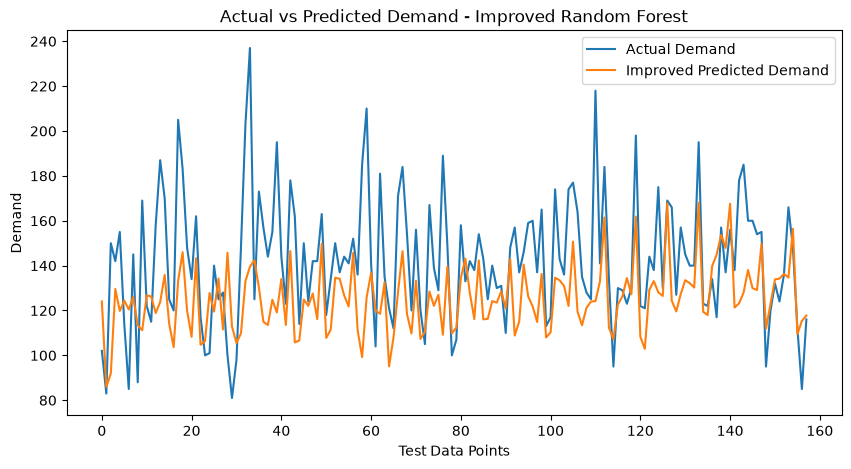

In [139]:
plt.figure(figsize=(10, 5))

plt.plot(y_test_improved.values, label="Actual Demand")
plt.plot(improved_pred, label="Improved Predicted Demand")

plt.xlabel("Test Data Points")
plt.ylabel("Demand")
plt.title("Actual vs Predicted Demand - Improved Random Forest")
plt.legend()
plt.show()

In [140]:
basic_features = [
    "day_of_week",
    "month",
    "year",
    "week_of_year",
    "is_weekend"
]

basic_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

basic_rf.fit(
    train_data[basic_features],
    train_data["demand"]
)

basic_pred = basic_rf.predict(
    test_data[basic_features]
)

basic_mae = mean_absolute_error(
    test_data["demand"],
    basic_pred
)

basic_rmse = np.sqrt(
    mean_squared_error(test_data["demand"], basic_pred)
)

basic_r2 = r2_score(
    test_data["demand"],
    basic_pred
)

print("Basic Time-Based Random Forest MAE:", basic_mae)
print("Basic Time-Based Random Forest RMSE:", basic_rmse)
print("Basic Time-Based Random Forest R²:", basic_r2)

Basic Time-Based Random Forest MAE: 26.444767932489448
Basic Time-Based Random Forest RMSE: 33.81773362801806
Basic Time-Based Random Forest R²: -0.452268060564063


In [141]:
demand_model["time_index"] = range(len(demand_model))

demand_model[[
    "arrival_date",
    "time_index",
    "demand"
]].head()

,arrival_date,time_index,demand
7,2015-07-08,0,42
8,2015-07-09,1,41
9,2015-07-10,2,48
10,2015-07-11,3,58
11,2015-07-12,4,49


In [142]:
train_size = int(len(demand_model) * 0.8)

train_data = demand_model.iloc[:train_size].copy()
test_data = demand_model.iloc[train_size:].copy()

print("Training data:", train_data.shape)
print("Testing data:", test_data.shape)

Training data: (628, 11)
Testing data: (158, 11)


In [143]:
improved_features = [
    "day_of_week",
    "month",
    "year",
    "week_of_year",
    "is_weekend",
    "lag_1",
    "lag_7",
    "rolling_7",
    "time_index"
]

X_train_final = train_data[improved_features]
y_train_final = train_data["demand"]

X_test_final = test_data[improved_features]
y_test_final = test_data["demand"]

final_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

final_rf.fit(X_train_final, y_train_final)

final_pred = final_rf.predict(X_test_final)

final_pred[:5]

array([123.01      ,  95.36333333,  96.67666667, 132.21666667,
       121.74666667])

In [144]:
final_mae = mean_absolute_error(y_test_final, final_pred)

final_rmse = np.sqrt(
    mean_squared_error(y_test_final, final_pred)
)

final_r2 = r2_score(y_test_final, final_pred)

print("Final Random Forest MAE:", final_mae)
print("Final Random Forest RMSE:", final_rmse)
print("Final Random Forest R²:", final_r2)

Final Random Forest MAE: 28.813966244725737
Final Random Forest RMSE: 35.89888076954948
Final Random Forest R²: -0.636513549554367


In [145]:
day6_comparison = pd.DataFrame({
    "Model": [
        "Basic Time-Based Random Forest",
        "Improved Random Forest",
        "Final Random Forest + Time Index"
    ],
    "MAE": [
        basic_mae,
        improved_mae,
        final_mae
    ],
    "RMSE": [
        basic_rmse,
        improved_rmse,
        final_rmse
    ],
    "R2": [
        basic_r2,
        improved_r2,
        final_r2
    ]
})

day6_comparison

,Model,MAE,RMSE,R2
0,Basic Time-Based Random Forest,26.444768,33.817734,-0.452268
1,Improved Random Forest,22.797975,30.523246,-0.183094
2,Final Random Forest + Time Index,28.813966,35.898881,-0.636514


## Model Improvement Findings

- Additional time-based features and historical demand features were created.
- The lag_1, lag_7, and rolling_7 features were created using previous demand values.
- A time-based train-test split was used to maintain the chronological order of the data.
- The improved Random Forest model performed better than the basic time-based Random Forest.
- The Improved Random Forest achieved an MAE of approximately 22.80 bookings.
- The Improved Random Forest achieved an RMSE of approximately 30.52 bookings.
- The Improved Random Forest achieved an R² score of approximately -0.183.
- The rolling_7 feature had the highest feature importance at approximately 0.504.
- Adding the time_index feature did not improve model performance and resulted in worse evaluation scores.
- Among the models evaluated using the time-based test set, the Improved Random Forest was the best-performing model.
- The negative R² indicates that the current model still has limitations in predicting future hotel booking demand accurately.

#  Final Model & Business Interpretation

## Objective

The objective of this step is to finalize the best-performing demand prediction model and interpret its results from a business perspective.

The final model will be used to:

- Generate hotel booking demand predictions.
- Analyze prediction errors.
- Compare actual and predicted demand.
- Summarize model performance.
- Interpret the results for hotel demand planning.
- Discuss limitations and possible future improvements.

In [146]:
final_demand_predictions = improved_rf.predict(X_test_improved)

final_demand_predictions[:10]

array([124.04666667,  85.92666667,  91.91      , 129.59333333,
       119.79333333, 124.41333333, 120.46666667, 126.01333333,
       113.38666667, 111.20666667])

In [147]:
final_results = pd.DataFrame({
    "Actual_Demand": y_test_improved.values,
    "Predicted_Demand": final_demand_predictions
})

final_results.head(10)

,Actual_Demand,Predicted_Demand
0,102,124.046667
1,83,85.926667
2,150,91.910000
3,142,129.593333
4,155,119.793333
5,114,124.413333
6,85,120.466667
7,145,126.013333
8,88,113.386667
9,169,111.206667


In [148]:
final_results["Error"] = (
    final_results["Actual_Demand"]
    - final_results["Predicted_Demand"]
)

final_results.head(10)

,Actual_Demand,Predicted_Demand,Error
0,102,124.046667,-22.046667
1,83,85.926667,-2.926667
2,150,91.910000,58.090000
3,142,129.593333,12.406667
4,155,119.793333,35.206667
5,114,124.413333,-10.413333
6,85,120.466667,-35.466667
7,145,126.013333,18.986667
8,88,113.386667,-25.386667
9,169,111.206667,57.793333


In [149]:
final_results["Absolute_Error"] = final_results["Error"].abs()

final_results.head(10)

,Actual_Demand,Predicted_Demand,Error,Absolute_Error
0,102,124.046667,-22.046667,22.046667
1,83,85.926667,-2.926667,2.926667
2,150,91.910000,58.090000,58.090000
3,142,129.593333,12.406667,12.406667
4,155,119.793333,35.206667,35.206667
5,114,124.413333,-10.413333,10.413333
6,85,120.466667,-35.466667,35.466667
7,145,126.013333,18.986667,18.986667
8,88,113.386667,-25.386667,25.386667
9,169,111.206667,57.793333,57.793333


In [150]:
print("Mean Absolute Error:", final_results["Absolute_Error"].mean())
print("Maximum Absolute Error:", final_results["Absolute_Error"].max())
print("Minimum Absolute Error:", final_results["Absolute_Error"].min())

Mean Absolute Error: 22.797974683544304
Maximum Absolute Error: 97.47666666666666
Minimum Absolute Error: 0.346666666666664


In [151]:
final_results["arrival_date"] = test_data["arrival_date"].values

largest_errors = final_results.sort_values(
    by="Absolute_Error",
    ascending=False
)

largest_errors.head(10)

,Actual_Demand,Predicted_Demand,Error,Absolute_Error,arrival_date
33,237,139.523333,97.476667,97.476667,2017-04-29
110,218,124.183333,93.816667,93.816667,2017-07-15
58,185,99.223333,85.776667,85.776667,2017-05-24
59,210,125.786667,84.213333,84.213333,2017-05-25
76,189,109.203333,79.796667,79.796667,2017-06-11
39,195,119.130000,75.870000,75.870000,2017-05-05
17,205,133.270000,71.730000,71.730000,2017-04-13
32,203,133.070000,69.930000,69.930000,2017-04-28
13,187,123.740000,63.260000,63.260000,2017-04-09
62,181,118.510000,62.490000,62.490000,2017-05-28


In [152]:
final_results["Percentage_Error"] = (
    final_results["Absolute_Error"]
    / final_results["Actual_Demand"]
) * 100

final_results.head(10)

,Actual_Demand,Predicted_Demand,Error,Absolute_Error,arrival_date,Percentage_Error
0,102,124.046667,-22.046667,22.046667,2017-03-27,21.614379
1,83,85.926667,-2.926667,2.926667,2017-03-28,3.526104
2,150,91.910000,58.090000,58.090000,2017-03-29,38.726667
3,142,129.593333,12.406667,12.406667,2017-03-30,8.737089
4,155,119.793333,35.206667,35.206667,2017-03-31,22.713978
5,114,124.413333,-10.413333,10.413333,2017-04-01,9.134503
6,85,120.466667,-35.466667,35.466667,2017-04-02,41.725490
7,145,126.013333,18.986667,18.986667,2017-04-03,13.094253
8,88,113.386667,-25.386667,25.386667,2017-04-04,28.848485
9,169,111.206667,57.793333,57.793333,2017-04-05,34.197239


In [153]:
mean_percentage_error = final_results["Percentage_Error"].mean()

print("Mean Percentage Error:", mean_percentage_error)

Mean Percentage Error: 15.059125913415455


In [154]:
final_performance = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²",
        "Mean Percentage Error"
    ],
    "Value": [
        improved_mae,
        improved_rmse,
        improved_r2,
        mean_percentage_error
    ]
})

final_performance

,Metric,Value
0,MAE,22.797975
1,RMSE,30.523246
2,R²,-0.183094
3,Mean Percentage Error,15.059126


## Business Interpretation

The demand prediction model can provide an approximate estimate of daily hotel booking demand based on historical booking patterns.

The model's MAE of approximately 22.80 bookings indicates that the predicted daily demand differs from the actual demand by around 23 bookings on average.

The model can potentially support hotel management in:

- Planning staffing levels according to expected demand.
- Preparing resources for high-demand periods.
- Supporting room availability and inventory planning.
- Identifying periods where demand may increase.
- Assisting operational planning based on historical demand patterns.

However, the negative R² score indicates that the current model has limitations in predicting future demand accurately. Sudden demand spikes are particularly difficult for the current feature set to capture.

## Final Project Conclusion

This project analyzed hotel booking data and developed a machine learning approach for predicting daily hotel booking demand.

The data was first cleaned and explored through exploratory data analysis. Feature engineering was then performed by creating daily booking demand and extracting time-based and historical demand features.

Several models were evaluated, including a baseline model, Linear Regression, and Random Forest. Random Forest provided the best performance among the initial models. Additional historical demand features were then introduced during model improvement.

The final selected model was the Improved Random Forest. It achieved an MAE of approximately 22.80 bookings, an RMSE of approximately 30.52 bookings, and a mean absolute percentage error of approximately 15.06%.

Although the model provides useful approximate demand estimates, its negative R² score indicates that the current feature set does not fully capture future demand variation. In particular, sudden changes and high-demand spikes remain difficult to predict.

Future improvements could include additional information such as holidays, special events, weather conditions, hotel capacity, booking channels, pricing information, and more advanced time-series forecasting techniques.

In [155]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    random_state=42
)

gbr_model.fit(X_train_final, y_train_final)

gbr_pred = gbr_model.predict(X_test_final)

gbr_mae = mean_absolute_error(y_test_final, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test_final, gbr_pred))
gbr_r2 = r2_score(y_test_final, gbr_pred)

print("Gradient Boosting MAE:", gbr_mae)
print("Gradient Boosting RMSE:", gbr_rmse)
print("Gradient Boosting R²:", gbr_r2)

Gradient Boosting MAE: 38.65977649855156
Gradient Boosting RMSE: 45.7599358575251
Gradient Boosting R²: -1.659062847865148


In [156]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (628, 9)
Scaled testing data: (158, 9)


In [157]:
from sklearn.neural_network import MLPRegressor

ann_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    random_state=42
)

ann_model.fit(X_train_scaled, y_train_final)

ann_pred = ann_model.predict(X_test_scaled)

ann_mae = mean_absolute_error(y_test_final, ann_pred)
ann_rmse = np.sqrt(mean_squared_error(y_test_final, ann_pred))
ann_r2 = r2_score(y_test_final, ann_pred)

print("ANN MAE:", ann_mae)
print("ANN RMSE:", ann_rmse)
print("ANN R²:", ann_r2)

ANN MAE: 22.254582144411952
ANN RMSE: 29.156206518182614
ANN R²: -0.0794929828600559


C:\Users\Win11\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [158]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "ANN"
    ],
    "MAE": [
        linear_mae,
        improved_mae,
        gbr_mae,
        ann_mae
    ],
    "RMSE": [
        linear_rmse,
        improved_rmse,
        gbr_rmse,
        ann_rmse
    ],
    "R2": [
        linear_r2,
        improved_r2,
        gbr_r2,
        ann_r2
    ]
})

model_comparison.sort_values(by="MAE")

,Model,MAE,RMSE,R2
3,ANN,22.254582,29.156207,-0.079493
1,Random Forest,22.797975,30.523246,-0.183094
0,Linear Regression,26.511504,33.066320,0.206406
2,Gradient Boosting,38.659776,45.759936,-1.659063


In [160]:
model_comparison.loc[
    model_comparison["Model"] == "ANN",
    "R2"
] = ann_r2

model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,26.511504,33.066320,0.206406
1,Random Forest,22.797975,30.523246,-0.183094
2,Gradient Boosting,38.659776,45.759936,-1.659063
3,ANN,22.254582,29.156207,-0.079493


In [161]:
final_lr = LinearRegression()

final_lr.fit(X_train_final, y_train_final)

final_lr_pred = final_lr.predict(X_test_final)

final_lr_mae = mean_absolute_error(y_test_final, final_lr_pred)
final_lr_rmse = np.sqrt(mean_squared_error(y_test_final, final_lr_pred))
final_lr_r2 = r2_score(y_test_final, final_lr_pred)

print("Final Linear Regression MAE:", final_lr_mae)
print("Final Linear Regression RMSE:", final_lr_rmse)
print("Final Linear Regression R²:", final_lr_r2)

Final Linear Regression MAE: 22.432492917219793
Final Linear Regression RMSE: 28.747222490963726
Final Linear Regression R²: -0.049420560083317966


In [162]:
final_model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "ANN"
    ],
    "MAE": [
        final_lr_mae,
        improved_mae,
        gbr_mae,
        ann_mae
    ],
    "RMSE": [
        final_lr_rmse,
        improved_rmse,
        gbr_rmse,
        ann_rmse
    ],
    "R2": [
        final_lr_r2,
        improved_r2,
        gbr_r2,
        ann_r2
    ]
})

final_model_comparison

,Model,MAE,RMSE,R2
0,Linear Regression,22.432493,28.747222,-0.049421
1,Random Forest,22.797975,30.523246,-0.183094
2,Gradient Boosting,38.659776,45.759936,-1.659063
3,ANN,22.254582,29.156207,-0.079493


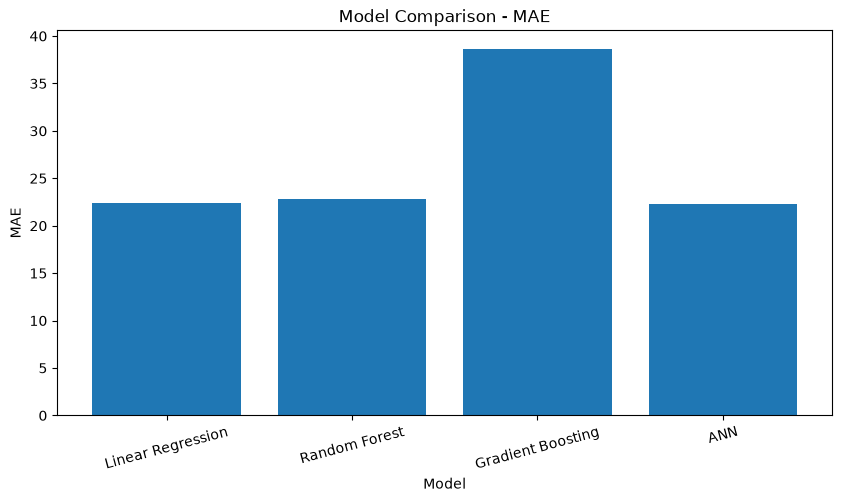

In [163]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison - MAE")
plt.xticks(rotation=15)

plt.show()

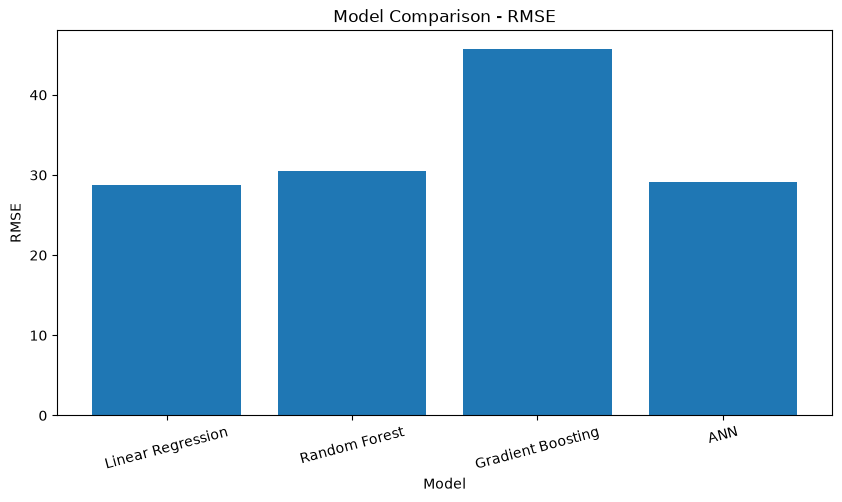

In [164]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["RMSE"]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")
plt.xticks(rotation=15)

plt.show()

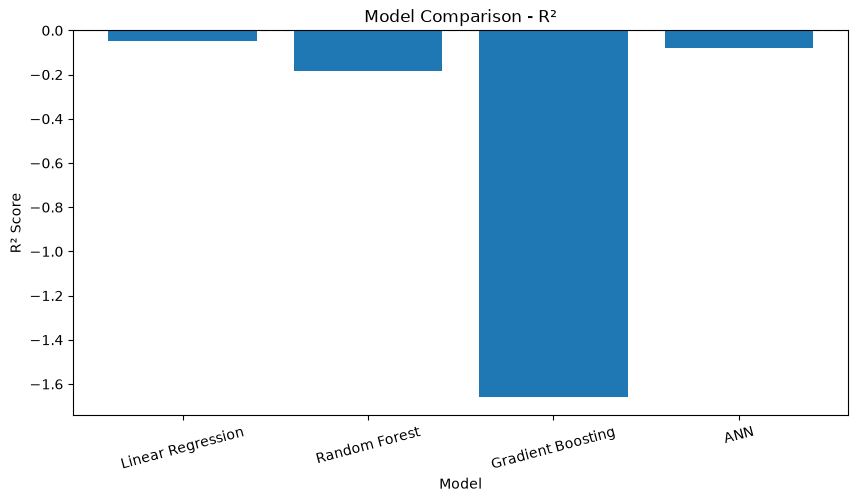

In [165]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_model_comparison["Model"],
    final_model_comparison["R2"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("Model Comparison - R²")
plt.xticks(rotation=15)

plt.axhline(y=0, linestyle="--")

plt.show()

## Final Model Selection

Based on the evaluation of all four models, Linear Regression achieved the best RMSE and R² scores, while ANN achieved the lowest MAE.

The model performance was evaluated using MAE, RMSE, and R². Since no single model performed best across all three metrics, Linear Regression is selected as the final model because it provides the best overall performance in terms of RMSE and R².

Gradient Boosting showed the weakest performance among the evaluated models.

In [166]:
new_input = pd.DataFrame({
    "day_of_week": [2],
    "month": [8],
    "year": [2017],
    "week_of_year": [31],
    "is_weekend": [0],
    "lag_1": [120],
    "lag_7": [115],
    "rolling_7": [118],
    "time_index": [793]
})

new_prediction = final_lr.predict(new_input)

print("Predicted Hotel Demand:", new_prediction[0])

Predicted Hotel Demand: 124.74247250215558


## New / Unseen Input Prediction

A new unseen input was provided to the final Linear Regression model to demonstrate real-world prediction.

The model predicted a hotel demand of approximately **124.74** for the given input conditions.

This demonstrates that the trained model can be used to estimate future hotel demand based on historical demand and time-related features.